In [1]:
from matplotlib import pyplot as plt
import pandas as pd
import glob

FIG_SIZE_X = 10
FIG_SIZE_Y = 5
DPI = 60
FONT_SIZE = 18

#INPUT_FILE  = 'gval.csv'
INPUT_FILES = sorted(glob.glob("./gval-*.csv"))
OUTPUT_FILE = 'gval.pkl'

%matplotlib inline

In [2]:
# read csv file
#df = pd.read_csv(INPUT_FILE)
#pd.set_option('display.max_columns', 20)
#pd.set_option('display.max_rows', 61)
#df

counter = 0
for x in INPUT_FILES:
  print(x)
  if counter == 0:
    df = pd.read_csv(x)
    counter += 1
    continue
  df += pd.read_csv(x)
  counter += 1
  
df /= counter

./gval-1.csv
./gval-2.csv


In [3]:
label = {'H^0'   : 'H',   'H_2^0'  : 'H2',   'H2O2^0' : 'H2O2', 'H3O^1': 'H3Op', 
         'HO_2^0': 'HO2', 'HO_2^-1': 'HO2m', 'O^0'    : 'O',    'O_2^0': 'O2', 
         'O_2^-1': 'O2m', 'O_3^0'  : 'O3',   'O_3^-1' : 'O3m',   'OH^0': 'OH',
         'OH^-1' : 'OHm', 'O^-1'   : 'Om',   'e_aq^-1': 'e_aq'}

In [4]:
def plot(x, y, title):
    plt.figure(figsize = (FIG_SIZE_X, FIG_SIZE_Y), dpi = DPI)
    plt.plot(x, y, label = "Geant4-DNA", linewidth = 3.0)
    plt.grid(True)
    plt.title(title, fontsize = FONT_SIZE)
    plt.xlabel("Time (ps)", fontsize = FONT_SIZE)
    plt.ylabel("G-value", fontsize = FONT_SIZE)
    plt.xscale("log")
    plt.legend(fontsize = FONT_SIZE)
    plt.tick_params(labelsize = FONT_SIZE)
    plt.show()

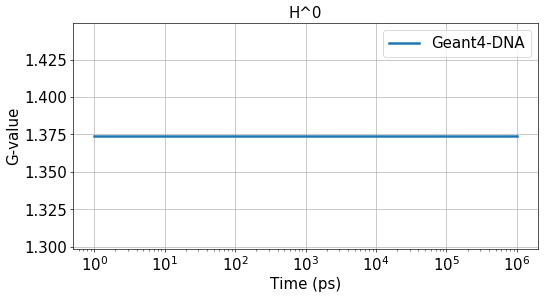

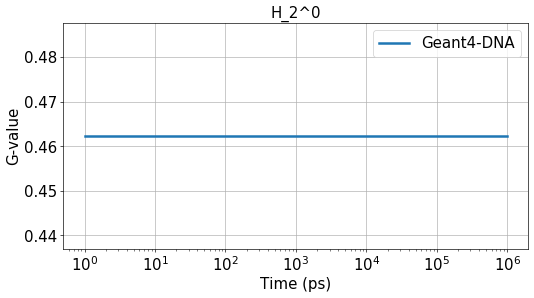

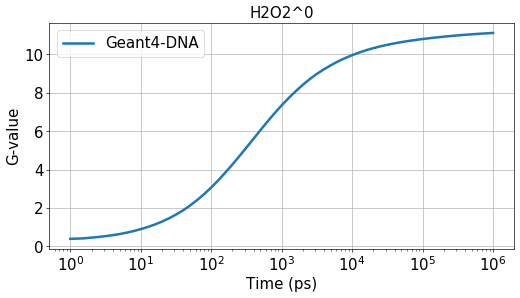

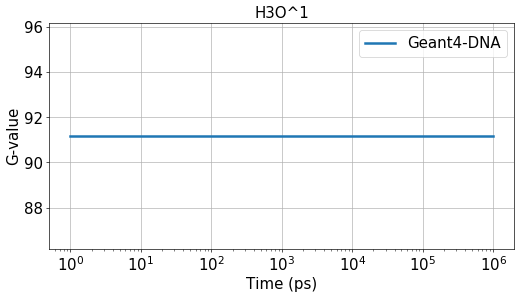

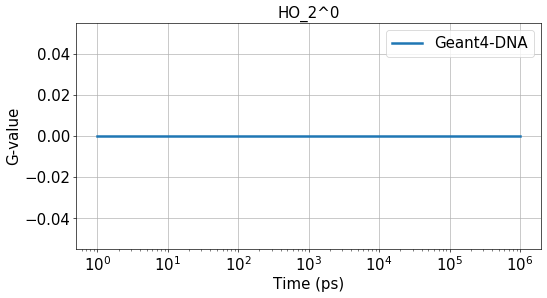

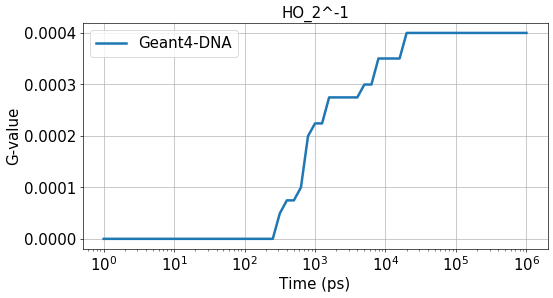

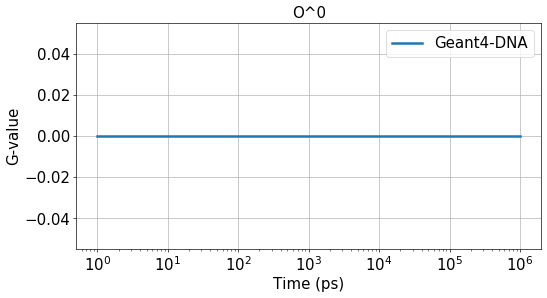

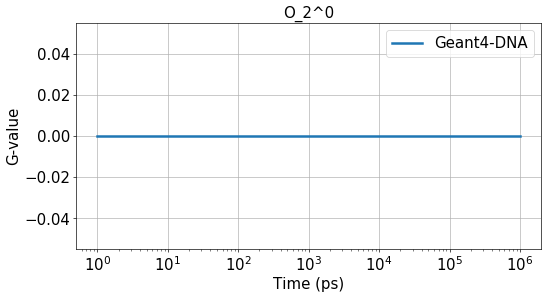

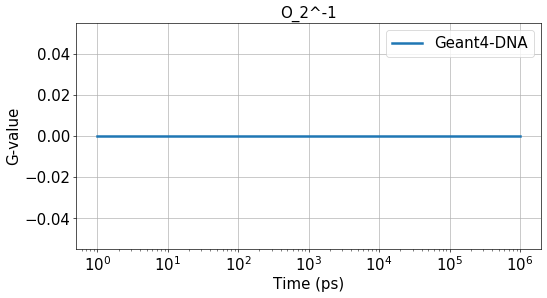

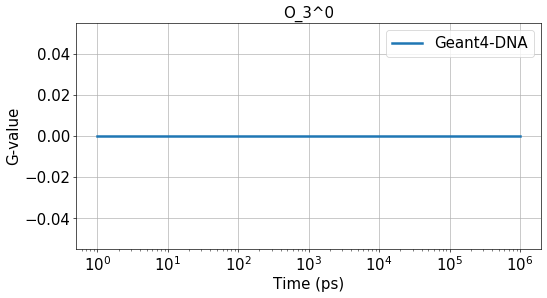

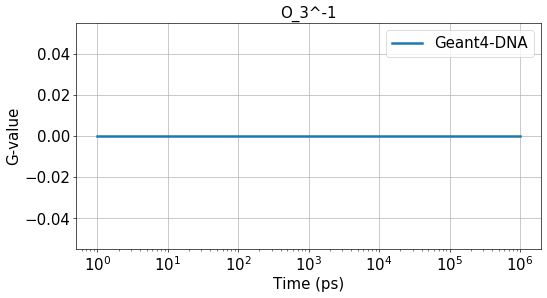

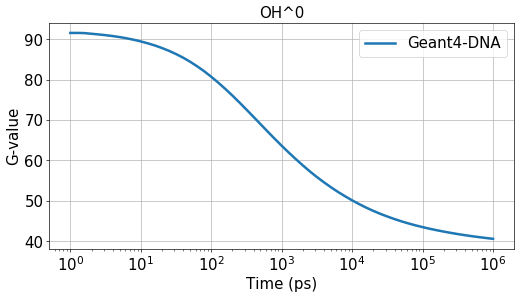

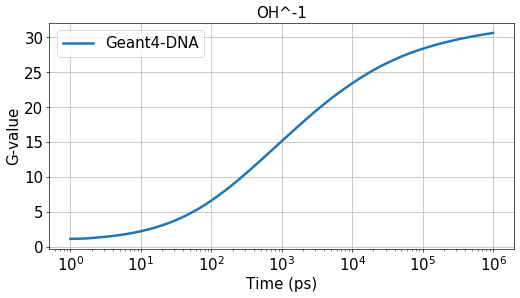

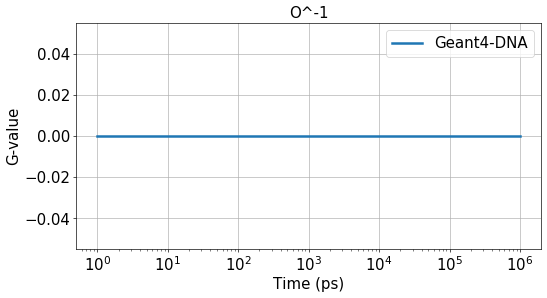

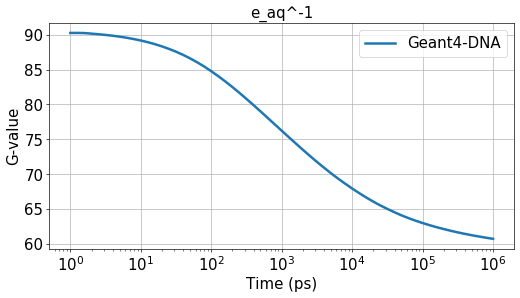

In [5]:
# make G-value plots
output = {"time": df['Time_ps'].values}
for x in df.columns:
    if x == 'Time_ps' or x == "None^0":
      continue
    plot(df['Time_ps'], df[x], x)
    output[label[x]] = df[x].values

# make data frame with Pandas and save as pickle file
pd.DataFrame.from_dict(output).to_pickle(OUTPUT_FILE)